In [1]:
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

In [2]:
import glob

for f in glob.glob("/kaggle/input/**/*", recursive=True):
    print(f)

/kaggle/input/datasets
/kaggle/input/datasets/rose31
/kaggle/input/datasets/rose31/classifier-keys
/kaggle/input/datasets/rose31/whole-corpus
/kaggle/input/datasets/rose31/10k-tokens
/kaggle/input/datasets/rose31/classifier-keys/kinyarwanda_blind_annotation_answer_key.csv
/kaggle/input/datasets/rose31/whole-corpus/kinyarwanda_multidomain_candidates.csv
/kaggle/input/datasets/rose31/10k-tokens/kinyarwanda_blind_annotation_10k_per_domain.xlsx


In [3]:
CORPUS_PATH = "/kaggle/input/datasets/rose31/whole-corpus/kinyarwanda_multidomain_candidates.csv"

BLIND_PATH = "/kaggle/input/datasets/rose31/10k-tokens/kinyarwanda_blind_annotation_10k_per_domain.xlsx"

ANSWER_KEY_PATH = "/kaggle/input/datasets/rose31/classifier-keys/kinyarwanda_blind_annotation_answer_key.csv"

In [4]:
corpus = pd.read_csv(CORPUS_PATH)

blind = pd.read_excel(BLIND_PATH)

answer_key = pd.read_csv(ANSWER_KEY_PATH)

print("Corpus:", corpus.shape)
print("Blind sample:", blind.shape)
print("Answer key:", answer_key.shape)

display(corpus.head())
display(blind.head())
display(answer_key.head())

Corpus: (50711, 9)
Blind sample: (1726, 4)
Answer key: (1726, 4)


,id,language,domain,raw_text,source_dataset,source_split,license,review_status,notes
0,kin_health_000001,kin,health,"Ibinini by'umuhondo, umweru w'umutuku ndetse n...",DigitalUmuganda/Afrivoice_Kinyarwanda,train,CC-BY-4.0,unreviewed,Loaded through Professor/kinyarwanda-speech-da...
1,kin_health_000002,kin,health,Icyumba cyo kwa muganga kirimo ibikoresho bige...,DigitalUmuganda/Afrivoice_Kinyarwanda,train,CC-BY-4.0,unreviewed,Loaded through Professor/kinyarwanda-speech-da...
2,kin_health_000003,kin,health,Abaturage bagiye batandukanye bageze mu za buk...,DigitalUmuganda/Afrivoice_Kinyarwanda,train,CC-BY-4.0,unreviewed,Loaded through Professor/kinyarwanda-speech-da...
3,kin_health_000004,kin,health,Abantu benshi bicaye ku ntebe z'urubaho ziri h...,DigitalUmuganda/Afrivoice_Kinyarwanda,train,CC-BY-4.0,unreviewed,Loaded through Professor/kinyarwanda-speech-da...
4,kin_health_000005,kin,health,"Inyubako nini, y'igorofa, isa umuhondo. Imbere...",DigitalUmuganda/Afrivoice_Kinyarwanda,train,CC-BY-4.0,unreviewed,Loaded through Professor/kinyarwanda-speech-da...


,sample_id,raw_text,label,identifier
0,S0001,Iri ni itsinda ry'abaganga aho bari muri opera...,NaN,NaN
1,S0002,(i) ubusobanuro ku by'ingenzi biranga serivisi...,NaN,NaN
2,S0003,"Abantu babiri bambaye imyenda y'imyitozo, umwe...",NaN,NaN
3,S0004,Ibihingwa ngandubukungu n'ibihingwa nganduraru...,NaN,NaN
4,S0005,"Ubucuruzi icuruzwamo ikinyobwa cy'amata, umucu...",NaN,NaN


,sample_id,actual_domain,original_id,word_count
0,S0001,health,kin_health_001112,30
1,S0002,law,kin_law_004503,10
2,S0003,health,kin_health_005950,23
3,S0004,agriculture,kin_agriculture_002898,43
4,S0005,finance,kin_finance_001456,27


In [5]:
print(corpus["domain"].value_counts())

print("\nClasses:")
print(sorted(corpus["domain"].unique()))

domain
law            17305
agriculture    11520
finance        10902
health         10731
telecoms         253
Name: count, dtype: int64

Classes:
['agriculture', 'finance', 'health', 'law', 'telecoms']


In [6]:
blind_ids = set(
    answer_key["original_id"]
    .dropna()
    .astype(str)
)

blind_texts = set(
    blind["raw_text"]
    .dropna()
    .astype(str)
    .str.strip()
)

training_data = corpus[
    ~corpus["id"].astype(str).isin(blind_ids)
].copy()

training_data = training_data[
    ~training_data["raw_text"]
    .astype(str)
    .str.strip()
    .isin(blind_texts)
].copy()

print("Original corpus:", len(corpus))
print("After removing blind data:", len(training_data))
print("Removed:", len(corpus) - len(training_data))

Original corpus: 50711
After removing blind data: 48985
Removed: 1726


In [7]:
print(
    training_data["raw_text"]
    .astype(str)
    .isin(blind_texts)
    .sum()
)

0


In [8]:
training_data = training_data[
    training_data["raw_text"]
    .notna()
].copy()

training_data["raw_text"] = (
    training_data["raw_text"]
    .astype(str)
    .str.strip()
)

training_data = training_data[
    training_data["raw_text"] != ""
].copy()

print(training_data.shape)

(48985, 9)


In [9]:
X = training_data["raw_text"]
y = training_data["domain"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Validation:", len(X_val))

print("\nTraining classes:")
print(y_train.value_counts())

Training: 39188
Validation: 9797

Training classes:
domain
law            13373
agriculture     8913
finance         8432
health          8298
telecoms         172
Name: count, dtype: int64


In [10]:
features = FeatureUnion([
    
    (
        "word_tfidf",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
            sublinear_tf=True
        )
    ),

    (
        "char_tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True
        )
    )

])

In [11]:
model = Pipeline([
    
    ("features", features),

    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )

])

In [12]:
model.fit(
    X_train,
    y_train
)

print("Training complete.")

Training complete.


In [13]:
classifier = model.named_steps["classifier"]

print("Iterations used:", classifier.n_iter_)

Iterations used: [74]


In [15]:
val_pred = model.predict(X_val)

accuracy = accuracy_score(
    y_val,
    val_pred
)

macro_f1 = f1_score(
    y_val,
    val_pred,
    average="macro"
)

print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))

print("\nClassification report:\n")

print(
    classification_report(
        y_val,
        val_pred,
        digits=4
    )
)

Accuracy: 0.9457
Macro F1: 0.9486

Classification report:

              precision    recall  f1-score   support

 agriculture     0.9406    0.9309    0.9357      2229
     finance     0.9083    0.9118    0.9100      2108
      health     0.9124    0.9185    0.9154      2074
         law     0.9931    0.9931    0.9931      3343
    telecoms     0.9773    1.0000    0.9885        43

    accuracy                         0.9457      9797
   macro avg     0.9463    0.9509    0.9486      9797
weighted avg     0.9458    0.9457    0.9457      9797



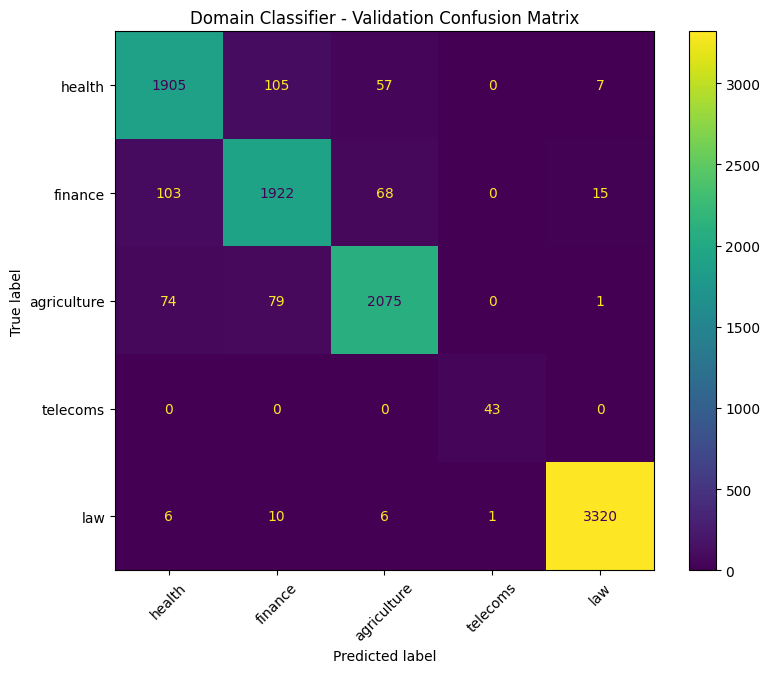

In [16]:
labels = [
    "health",
    "finance",
    "agriculture",
    "telecoms",
    "law"
]

cm = confusion_matrix(
    y_val,
    val_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "Domain Classifier - Validation Confusion Matrix"
)

plt.show()

In [20]:
def predict_domain(text):

    prediction = model.predict(
        [text]
    )[0]

    probabilities = model.predict_proba(
        [text]
    )[0]

    classes = model.classes_

    confidence = probabilities.max()

    return {
        "prediction": prediction,
        "confidence": round(
            float(confidence),
            4
        )
    }

In [25]:
example = """
Ikirango cy'abakina imikino y'imirwano, harimo abantu babiri bari kurwana, umwe yambaye umwenda w'umweru, undi yambaye umwenda w'ubururu, inyuma yabo hari izuba."""

predict_domain(example)

{'prediction': 'health', 'confidence': 0.8466}

In [22]:
blind_predictions = model.predict(
    blind["raw_text"].astype(str)
)

blind_probabilities = model.predict_proba(
    blind["raw_text"].astype(str)
)

blind["model_prediction"] = (
    blind_predictions
)

blind["model_confidence"] = (
    blind_probabilities.max(axis=1)
)

display(
    blind[
        [
            "sample_id",
            "raw_text",
            "label",
            "model_prediction",
            "model_confidence"
        ]
    ].head(20)
)

,sample_id,raw_text,label,model_prediction,model_confidence
0,S0001,Iri ni itsinda ry'abaganga aho bari muri opera...,NaN,health,0.976724
1,S0002,(i) ubusobanuro ku by'ingenzi biranga serivisi...,NaN,law,0.949950
2,S0003,"Abantu babiri bambaye imyenda y'imyitozo, umwe...",NaN,health,0.972185
3,S0004,Ibihingwa ngandubukungu n'ibihingwa nganduraru...,NaN,agriculture,0.980610
4,S0005,"Ubucuruzi icuruzwamo ikinyobwa cy'amata, umucu...",NaN,finance,0.981861
5,S0006,Imiterere y'inyandiko zishyirwa kuri izo nyand...,NaN,law,0.992025
6,S0007,Kwakira abaje bakugana vuba utabatindije bitum...,NaN,finance,0.605605
7,S0008,Abantu benshi bahagaze bambaye imyambaro iri m...,NaN,health,0.647684
8,S0009,Ingingo ya 165: uko inzego zifite ububasha mu ...,NaN,law,0.983683
9,S0010,"Kuri uyu wa Gatatu tariki 9 Kanama 2017, ibiny...",NaN,telecoms,0.975333


In [23]:
blind.to_excel(
    "/kaggle/working/blind_sample_with_model_predictions.xlsx",
    index=False
)

print("Saved.")

Saved.
